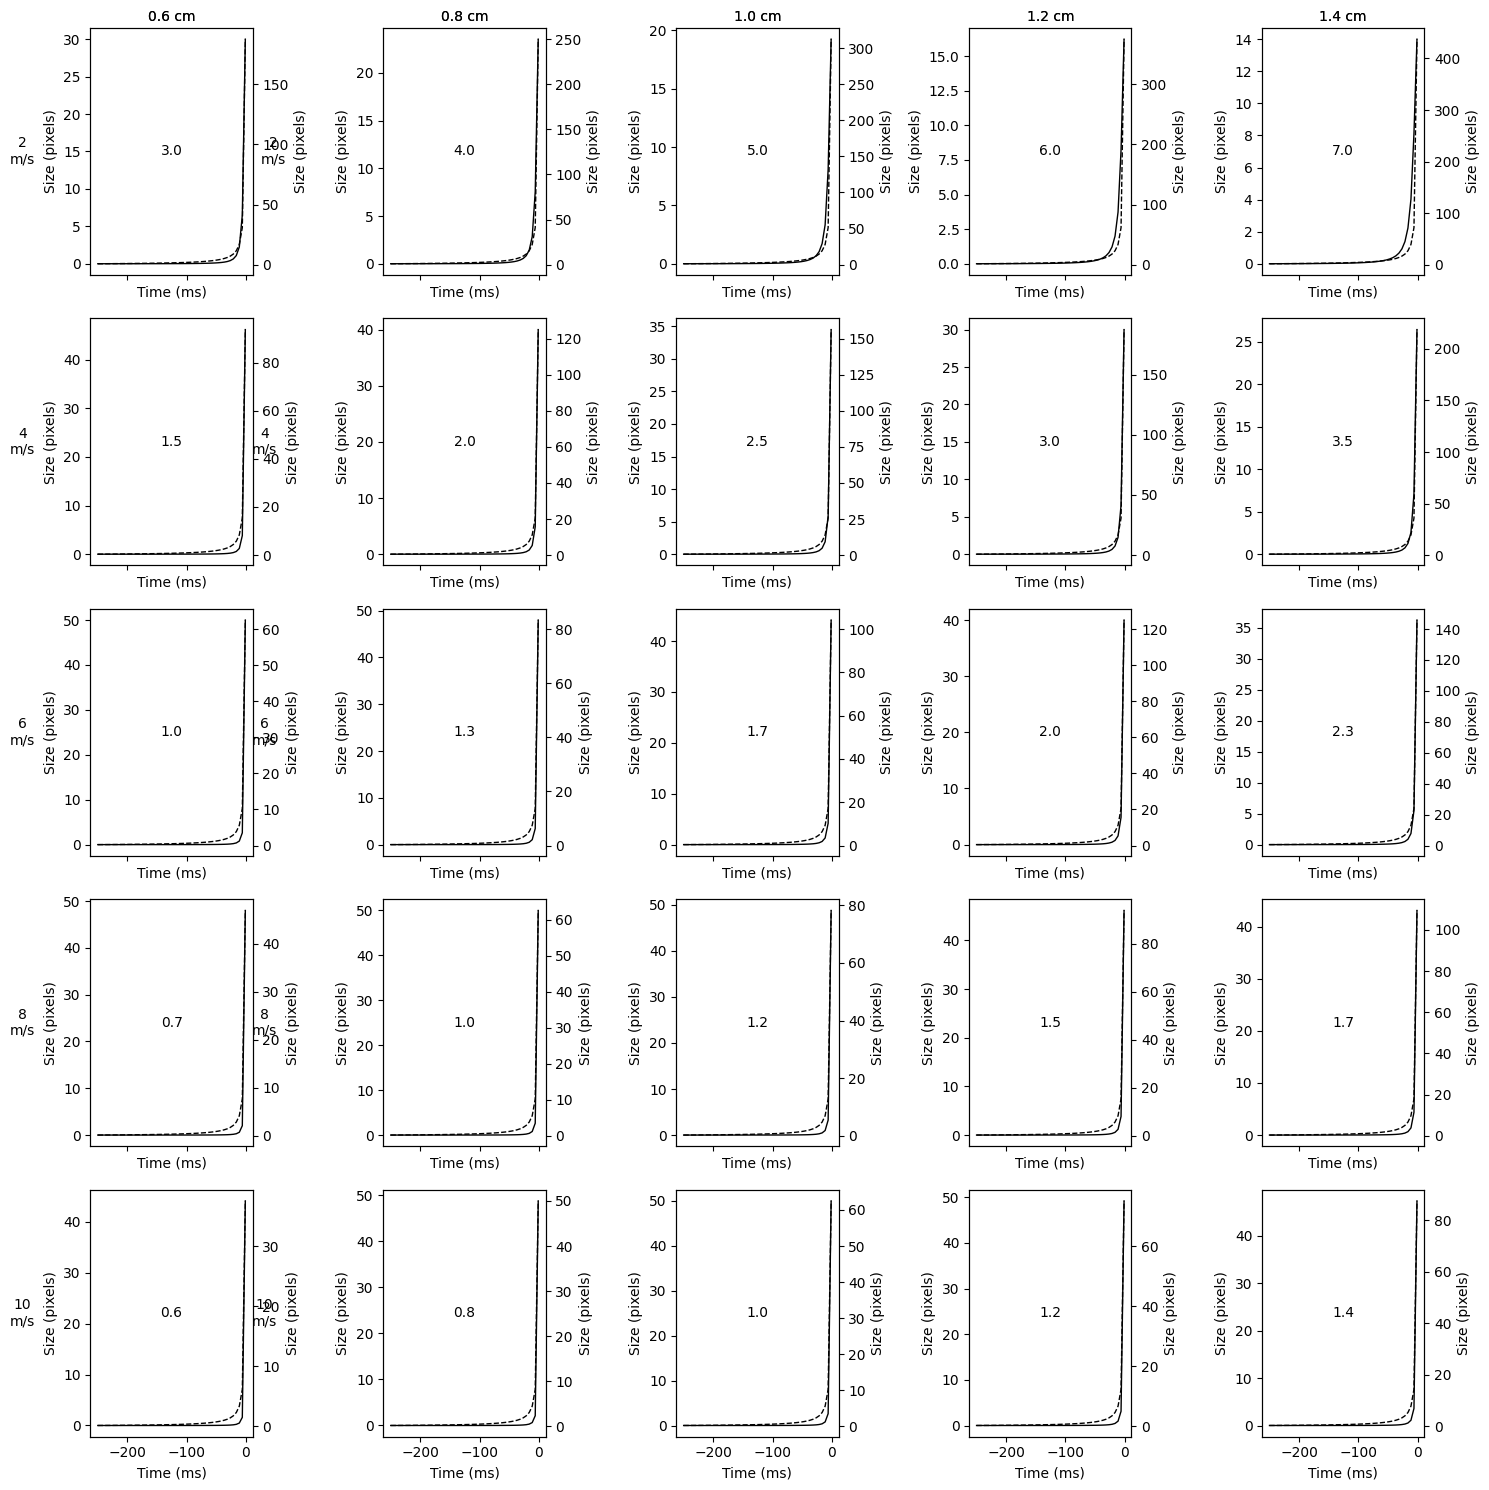

In [9]:
import math
import numpy as np
import matplotlib.pyplot as plt

PIXEL_SIZE_CM = 0.4

ls = np.array([6, 8, 10, 12, 14])/10 # get possible ls array (in cm)
vs = -np.array([2, 4, 6, 8, 10]) * 100 / 1000 # get possible vs array (in cm/ms) - multiple by 100 to get cm from m, then divide by 1000 to get cm/ms

duration_ms = 250 # total duration of the stimulus
total_frames = int(duration_ms/1000 * 200) # total frames in the stimulus
t = -np.flip(np.linspace(1, duration_ms, total_frames)) # time vector in ms
plt.close('all')
fig, ax = plt.subplots(ncols=len(ls), nrows=len(vs), figsize=(15,15), sharex=True)

# loop over all stimuli combinations
for i, v in enumerate(vs):
    for j, l in enumerate(ls):
        # calculate the angular size of the circle
        theta = 2 * np.arctan(l / (v*t))

        # calculate the angular velcoity of the circle
        omega = -((l/v) / (t**2 + (l/v)**2))*100

        # calculate the RADIUS of the circle in cm
        l_screen_cm = (np.tan(theta/2) * 25)

        # convert to pixels
        l_screen_px = l_screen_cm / PIXEL_SIZE_CM

        # plot
        ax[i, j].plot(t, omega, 'k', linewidth=1)
        ax2 = ax[i, j].twinx()
        ax2.plot(t, l_screen_px, 'k--', linewidth=1)
        ax2.set_ylabel('Size (pixels)')
        
        ax[i, j].text(0.5, 0.5, f'{l/np.abs(v):.1f}', transform=ax[i, j].transAxes, ha='center', va='center')
        ax[i, j].set_ylabel('Size (pixels)')
        ax[i, j].set_xlabel('Time (ms)')
        
add_headers(fig, row_headers=[f"{int(-v*10)}\nm/s" for v in vs], col_headers=[f"{l} cm" for l in ls], rotate_row_headers=False)
plt.tight_layout()
plt.show()

In [3]:
import numpy as np

def add_headers(
    fig,
    *,
    row_headers=None,
    col_headers=None,
    row_pad=1,
    col_pad=5,
    rotate_row_headers=True,
    **text_kwargs
):
    # Based on https://stackoverflow.com/a/25814386

    axes = fig.get_axes()

    for ax in axes:
        sbs = ax.get_subplotspec()

        # Putting headers on cols
        if (col_headers is not None) and sbs.is_first_row():
            ax.annotate(
                col_headers[sbs.colspan.start],
                xy=(0.5, 1),
                xytext=(0, col_pad),
                xycoords="axes fraction",
                textcoords="offset points",
                ha="center",
                va="baseline",
                **text_kwargs,
            )

        # Putting headers on rows
        if (row_headers is not None) and sbs.is_first_col():
            ax.annotate(
                row_headers[sbs.rowspan.start],
                xy=(-1, 0.5),
                xytext=(-ax.yaxis.labelpad - row_pad, 0),
                xycoords=ax.yaxis.label,
                textcoords="offset points",
                ha="center",
                va="center",
                rotation=rotate_row_headers * 90,
                **text_kwargs,
            )


In [73]:
import numpy as np
import matplotlib.pyplot as plt
import math

def find_rv_timecourse(theta_min_in, theta_max_in, r_v_ratio, delta_t):
    
    display_frequency = 1/delta_t  # in Hz

    deg_to_rad = np.pi/180
    theta_max = theta_max_in * deg_to_rad
    theta_min = theta_min_in * deg_to_rad

    min_collision_time = r_v_ratio / np.tan(theta_max/2)  # time to collision for disc at theta_max.
    max_collision_time = r_v_ratio / np.tan(theta_min/2)  # time to collision for disc at theta_min.
    total_collision_time = max_collision_time - min_collision_time
    num_frames = math.ceil(total_collision_time * display_frequency)  # round up so we cover at least theta_min to theta_max.

    time_theta_array = np.zeros((num_frames, 4))

    time_theta_array[:, 0] = np.arange(-min_collision_time, -max_collision_time, -delta_t) # times
    time_theta_array[:, 1] = (180/np.pi) * 2 * np.arctan2(r_v_ratio, (np.abs(time_theta_array[:, 0]))) # degrees
    time_theta_array[:, 2] = 25 * np.tan(np.deg2rad(time_theta_array[:, 1]/2)) # cm
    time_theta_array[:, 3] = time_theta_array[:, 2] / 0.4 # pixels

    return time_theta_array

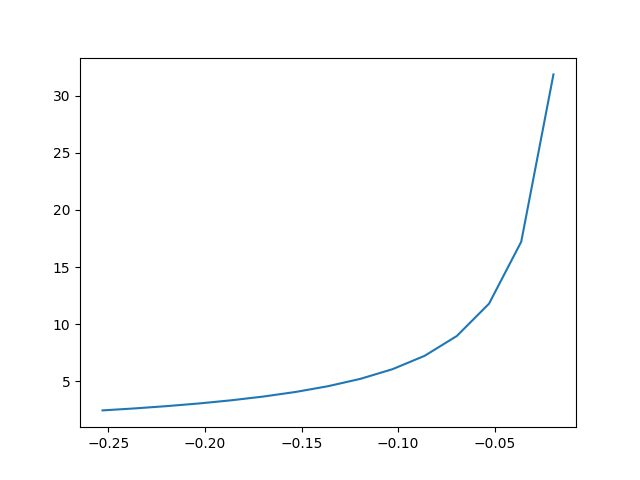

In [80]:
time_theta_array = find_rv_timecourse(4.5, 54, 0.01, 1/60)

plt.close('all')
fig = plt.figure()
plt.plot(time_theta_array[:, 0], time_theta_array[:, 3])
plt.show()

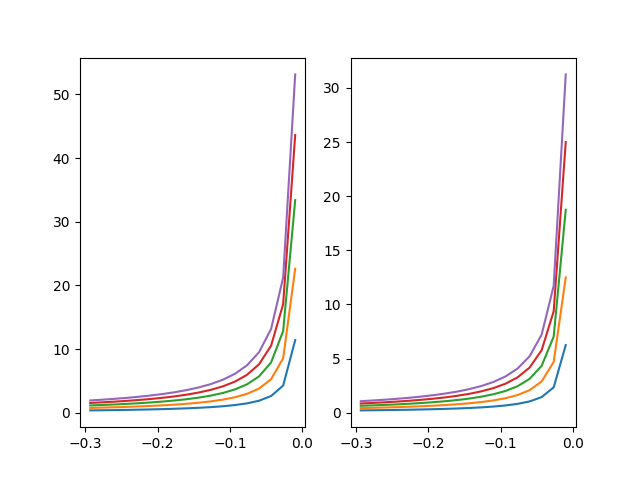

In [72]:
def get_looming(r_v_ratio, duration):
    t = -np.flip(np.arange(1/100, duration, 1/60))
    theta = 2 * np.arctan(-r_v_ratio / t)
    return t, theta

duration = 0.3
l_v_ratio = np.linspace(0.001, 0.005, 5)

%matplotlib widget
plt.close('all')
fig, axs = plt.subplots(ncols=2, nrows=1)

for l_v in l_v_ratio:
    t, theta = get_looming(l_v, duration)
    axs[0].plot(t, np.rad2deg(theta), label='Degrees')
    axs[1].plot(t, 25 * np.tan(theta/2) / 0.4,  label='Pixels')

plt.show()